# Rating Analysis

This notebook contains code to calculate and visualize:
 - mean persuasion across conditions
 - mean trust scores across conditions
 - mean scores for additional questions across conditions
 - engagement indicators
 - trust-persuasion correlation

Wilcoxon signed rank tests are performed on differences across conditions of:
 - trust
 - persuasion
 - additional questions


## Imports

In [1]:
import pandas as pd
from scipy.stats import wilcoxon, spearmanr
import matplotlib.pyplot as plt

## Sessions clean and filter

First the sessions and messages data were loaded from csv files and organnized. 

In [2]:
# read session data from csv and drop duplicate sessions incase
sessions = pd.read_csv("sessions_real8.csv")
sessions = sessions.drop_duplicates(subset=["participant_id", "question_index"])

# read messages data from csv and sort by ID and question index
messages = pd.read_csv("messages_real8.csv")
messages = messages.sort_values(["participant_id", "question_index", "id"]).reset_index(drop=True)

Here is what sessions looks like:

In [3]:
sessions.head()

,participant_id,question_index,dilemma_id,condition,dilemma_text,initial_rating,final_rating,user_stance,ai_stance,timer_expired
0,P001,0,D5,Aligned,STATEMENT: Classes should be grouped by abilit...,40,NaN,DISAGREE,AGREE,0
1,P002,0,D6,Misaligned,STATEMENT: Everyone should recieve participati...,70,80.0,AGREE,DISAGREE,1
2,P002,1,D2,Aligned,STATEMENT: 21 should be the legal driving age ...,0,10.0,DISAGREE,AGREE,1
3,P002,2,D4,Misaligned,STATEMENT: Anyone can succeed through hard wor...,25,10.0,DISAGREE,AGREE,0
4,P002,3,D5,Aligned,STATEMENT: Classes should be grouped by abilit...,50,50.0,NEUTRAL,CHALLENGE,0


Here is what messages looks like:

In [4]:
messages.head()

,id,participant_id,question_index,role,content
0,1,P001,0,user,If classes are grouped by ability there will b...
1,2,P001,0,assistant,I see your point about the wide range of ages ...
2,3,P002,0,user,"I rated it a 70 because, based on the type of ..."
3,4,P002,0,assistant,Participation awards undermine the true essenc...
4,5,P002,0,user,You are straying away from the issue; rewards ...


## Filter Data For Completeness

The data was then filtered to only include participants who completed the entire experiment. 
This means:
- Participant IDs should appear 6 times in the sessions dataframe (6 dilemmas were completed)
- Three sessions should be in the aligned condition and three in the misaligned condition
- All sessions should have a final rating (to ensure the system didn't crash on the last question)


In [5]:
### helper function

In [6]:
def is_complete(pid, sessions_df):
    participant_sessions = sessions_df[sessions_df["participant_id"] == pid]
    
    # check 6 sessions
    if len(participant_sessions) != 6:
        return False
    
    #check 3 aligned and 3 misaligned
    condition_counts = participant_sessions["condition"].value_counts()
    if condition_counts.get("Aligned", 0) != 3:
        return False
    if condition_counts.get("Misaligned", 0) != 3:
        return False
    
    #check missing final ratings
    if participant_sessions["final_rating"].isna().any():
        missing = participant_sessions["final_rating"].isna().sum()
        return False
    
    return True

All unique participant IDs were checked for completeness with the `is_complete` helper function.
Participant 13 was manually excluded because they did not know that the sliders could move, resulting in multiple neutral initial and final ratings

In [7]:
### Check for participants

In [8]:
all_pids = sessions["participant_id"].unique()

#technical error
manual_exclude = ["P013"]
all_pids = [pid for pid in all_pids if pid not in manual_exclude]
complete_pids = []
excluded_pids = []

print("Completeness Check:")

# check all pids (except P013)
for pid in sorted(all_pids):
    complete = is_complete(pid, sessions)
    status = "Included" if complete else "Excluded"
    
    if complete:
        complete_pids.append(pid)
    else:
        excluded_pids.append(pid)

print(f"\nIncluded: {len(complete_pids)} participants: \n{complete_pids}\n")
print(f"Excluded: {len(excluded_pids)} participants:\n {excluded_pids}")

Completeness Check:

Included: 20 participants: 
['P002', 'P008', 'P011', 'P012', 'P014', 'P032', 'P036', 'P040', 'P045', 'P047', 'P053', 'P057', 'P061', 'P066', 'P067', 'P068', 'P069', 'P072', 'P075', 'P082']

Excluded: 15 participants:
 ['P001', 'P015', 'P020', 'P022', 'P027', 'P029', 'P039', 'P042', 'P052', 'P054', 'P058', 'P059', 'P065', 'P076', 'P081']


In [9]:
# clean dataframes to only include complete participants
sessions_clean = sessions[sessions["participant_id"].isin(complete_pids)].copy()
print(f"Sessions: {len(sessions_clean)}")
messages_clean = messages[messages["participant_id"].isin(complete_pids)].copy()
print(f"Messages: {len(messages_clean)}")

Sessions: 120
Messages: 770


## Calculate persuasion

Once the data was cleaned and filtered persuasion was calculates as:
- final rating minus initial rating if participant initially disagreed with the statement (rating less than 50)
- initital rating minus final rating if participant initially agreed with the statement (rating greater than 50)
- absolute value of final rating minus initial rating if participant was initially neutral (rating equal to 50)

In [10]:
def calculate_persuasion(row):
    initial = row["initial_rating"]
    final = row["final_rating"]

    #if initial disagreement, increase in rating implies persuasion
    if initial < 50:
        return final - initial
    #if initial agreement, decrease in rating implies persuasion
    elif initial > 50:
        return initial - final
    #if neutral any shift implies pursuasion
    else:
        return abs(final - initial)

Persuasion was calculated per row of the session data (each row corresponds to a dilemma)

In [11]:
sessions_clean["persuasion_score"] = sessions_clean.apply(calculate_persuasion, axis=1)

print(f"""Here is an example calculation on the first row of data: \n      The participant initially agreed, and after conversing with the misaligned agent they agreed even more. 
      The resulting persuasion score was negative: 70 - 80 = -10\n""")

print(sessions_clean[["participant_id", "question_index", "condition", "initial_rating", "final_rating", "persuasion_score"]].head(1))


Here is an example calculation on the first row of data: 
      The participant initially agreed, and after conversing with the misaligned agent they agreed even more. 
      The resulting persuasion score was negative: 70 - 80 = -10

  participant_id  question_index   condition  initial_rating  final_rating  \
1           P002               0  Misaligned              70          80.0   

   persuasion_score  
1             -10.0  


## Wilcoxen Test of persuasion

To perform statistical tests persuasion was first averaged across participants and conditions. Theis results in two persuasion scores for each particpant: One for the misaligned condition and one for the aligned condition:

In [12]:
#average persuasion to participant level 
participant_persuasion = (
    sessions_clean
    .groupby(["participant_id", "condition"])
    .agg(mean_persuasion=("persuasion_score", "mean"))
    .reset_index()
)

print("Mean persuasion at the participant level (first 4 rows):")
print(f"{participant_persuasion.head(4)}\n\n")

Mean persuasion at the participant level (first 4 rows):
  participant_id   condition  mean_persuasion
0           P002     Aligned         3.333333
1           P002  Misaligned       -11.666667
2           P008     Aligned         1.000000
3           P008  Misaligned        27.333333




Then, the dataframe was reshaped to have participant IDs as rows and "Aligned" and "Misaligned" as columns

In [84]:
#reshape
aligned = (participant_persuasion[participant_persuasion["condition"] == "Aligned"]
           .set_index("participant_id")["mean_persuasion"]
           .rename("aligned"))

misaligned = (participant_persuasion[participant_persuasion["condition"] == "Misaligned"]
              .set_index("participant_id")["mean_persuasion"]
              .rename("misaligned"))

wide = pd.concat([aligned, misaligned], axis=1).dropna()
print(wide.head(4))

print("\nMeans:")
print(f"Aligned mean persuasion: {wide['aligned'].mean():.3f}")
print(f"Misaligned mean persuasion: {wide['misaligned'].mean():.3f}\n\n")

                 aligned  misaligned
participant_id                      
P002            3.333333  -11.666667
P008            1.000000   27.333333
P011            2.000000   13.666667
P012            3.333333   28.666667

Means:
Aligned mean persuasion: 5.417
Misaligned mean persuasion: 6.117




Finally, a Wilcoxon signed rank test was performed on the persuasion scores across conditions

In [52]:
# wilcoxon
print(f"N = {len(wide)} participants")

stat, p = wilcoxon(wide["aligned"], wide["misaligned"])
print(f"\nWilcoxon W = {stat:.1f}, p = {p:.4f}")

N = 20 participants

Wilcoxon W = 104.0, p = 0.9702


## TIAS Score

The same statistical test was calculated on participants trust scores (calculated on a Likert 1 - 5 scale).
- Some questions were negatively scored
- The full trust scale can be found [here](https://pmc.ncbi.nlm.nih.gov/articles/PMC12098057/table/tab1/)

Qualtrics question IDs are downloaded in the following form {"ImportId":"QID4"}, so these were first stripped to only contain the ID itself

In [15]:
qualtrics_raw = pd.read_csv("updated_post_experiment_survey8.csv", header=None)

# extract QID codes from row 2
col_names = qualtrics_raw.iloc[2].apply(
    lambda x: x.split('"ImportId":"')[1].rstrip('"}') if '"ImportId":"' in str(x) else x
).tolist()
print(col_names)

['startDate","timeZone":"Europe/Amsterdam', 'endDate","timeZone":"Europe/Amsterdam', 'status', 'ipAddress', 'progress', 'duration', 'finished', 'recordedDate","timeZone":"Europe/Amsterdam', '_recordId', 'recipientLastName', 'recipientFirstName', 'recipientEmail', 'externalDataReference', 'locationLatitude', 'locationLongitude', 'distributionChannel', 'userLanguage', 'QID40_TEXT', 'QID1', 'QID2', 'QID3', 'QID4', 'QID5', 'QID6', 'QID7', 'QID8', 'QID9', 'QID10', 'QID11', 'QID12', 'QID14', 'QID18', 'QID15', 'QID19', 'QID16', 'QID17', 'QID39', 'QID42', 'QID43', 'QID44', 'QID49_TEXT', 'QID20', 'QID21', 'QID22', 'QID23', 'QID24', 'QID25', 'QID26', 'QID27', 'QID28', 'QID29', 'QID30', 'QID31', 'QID32', 'QID33', 'QID34', 'QID35', 'QID36', 'QID37', 'QID38', 'QID45', 'QID46', 'QID47', 'QID48_TEXT']


Then:
- Non data rows were dropped
- incomplete responses were dropped
- PID were put in the correct format
- P013 was excluded
- Questions were manually grouped by agent

In [54]:
#apply column names and keep only data rows
qualtrics = qualtrics_raw.iloc[3:].copy()
qualtrics.columns = col_names
qualtrics = qualtrics.reset_index(drop=True)

# drop incomplete responses
qualtrics = qualtrics.dropna(subset=["QID1"]).reset_index(drop=True)

#format participant ID
qualtrics["participant_id"] = qualtrics["QID40_TEXT"].apply(
    lambda x: str(x).strip() if pd.notna(x) and str(x).strip() != "" else None
)
qualtrics = qualtrics.dropna(subset=["participant_id"]).reset_index(drop=True)

#manually exclude due to technical difficulties
manual_exclude = ["P013"]
qualtrics = qualtrics[~qualtrics["participant_id"].isin(manual_exclude)].reset_index(drop=True)

print(f"Qualtrics responses: {len(qualtrics)}")
print(f"Participants: {qualtrics['participant_id'].tolist()}\n")


#star qs
STAR_TIAS = ["QID1", "QID2", "QID3", "QID4", "QID5",    
             "QID6", "QID7", "QID8", "QID9", "QID10", "QID11", "QID12"]  

#sun qs
SUN_TIAS =  ["QID20", "QID21", "QID22", "QID23", "QID24",  
             "QID25", "QID26", "QID27", "QID28", "QID29", "QID30", "QID31"]  

negative_items = 5

Qualtrics responses: 20
Participants: ['P002', 'P008', 'P011', 'P012', 'P014', 'P032', 'P036', 'P040', 'P047', 'P053', 'P057', 'P066', 'P061', 'P045', 'P067', 'P068', 'P069', 'P072', 'P075', 'P082']



The following function calculates the mean score of all TIAS questions, the first five items in the scale are negatively scored. For example "The system is deceptive"

In [55]:
def score_tias(df, items, n_negative):
    """
    Score TIAS for a given agent.
    Reverse scores for negative items.
    Returns mean score across all 12 items.
    """
    scores = df[items].astype(float).copy()

    # Reverse score negative items
    for col in items[:n_negative]:
        scores[col] = 6 - scores[col]

    return scores.mean(axis=1)

Scores are calculated for Star and Sun seperately

In [56]:
qualtrics["tias_star"] = score_tias(qualtrics, STAR_TIAS, negative_items)
qualtrics["tias_sun"] = score_tias(qualtrics, SUN_TIAS, negative_items)

print("TIAS SScores:")
print(qualtrics[["participant_id", "tias_star", "tias_sun"]].head(4))
print(f"\nMean TIAS Star (aligned): {qualtrics['tias_star'].mean():.3f}")
print(f"Mean TIAS Sun (misaligned):{qualtrics['tias_sun'].mean():.3f}")
print(f"Difference (aligned - misaligned):{(qualtrics['tias_star'] - qualtrics['tias_sun']).mean():.3f}")

TIAS SScores:
  participant_id  tias_star  tias_sun
0           P002   3.250000  1.583333
1           P008   3.583333  3.500000
2           P011   3.000000  3.750000
3           P012   2.416667  3.916667

Mean TIAS Star (aligned): 3.079
Mean TIAS Sun (misaligned):2.789
Difference (aligned - misaligned):0.311


In [19]:
qualtrics_tias = qualtrics.dropna(subset=["tias_star", "tias_sun"]).reset_index(drop=True)
print(f"N = {len(qualtrics_tias)} (dropped {len(qualtrics) - len(qualtrics_tias)} due to missing values)")

N = 19 (dropped 1 due to missing values)


### Wilcoxen 

A Wilcoxon test was performed on trust scores across conditions

In [57]:
print("Wilcoxon singned-rank test:")
print(f"N = {len(qualtrics_tias)}")

stat, p = wilcoxon(qualtrics_tias["tias_star"], qualtrics_tias["tias_sun"])
sig = "yes" if p < 0.05 else "ns"
print(f"W = {stat:.1f}, p = {p:.4f} {sig}")

Wilcoxon singned-rank test:
N = 19
W = 50.5, p = 0.2182 ns


## Additional Questions

The scores, difference, and signifigance was also reported for all 11 additional questions 

In [58]:
Question_pairs = [
    ("TIAS (overall trust score)",                          "tias_star", "tias_sun"),  
    ("I enjoyed conversing with the system",                "QID14", "QID32"),
    ("I was able to communicate successfully with the system", "QID18", "QID33"),
    ("I understood the system's arguments",                 "QID15", "QID34"),
    ("The system seemed to understand my arguments",        "QID19", "QID35"),
    ("I could see myself coming to an agreement",           "QID16", "QID36"),
    ("I was persuaded by the system",                       "QID17", "QID37"),
    ("The system communicated similar to me",               "QID39", "QID38"),
    ("I had control over the conversation",                 "QID42", "QID45"),
    ("I felt engaged in the conversation",                  "QID43", "QID46"),
    ("The conversations were mentally demanding",           "QID44", "QID47"),
]

### Table with sigifigance for overleaf

In [60]:
print(f"N = {len(qualtrics)} participants\n")
print(f"{'Question':<55} {'Star':>10} {'Sun':>10} {'Diff':>10} {'p-value':>10} {'Sig':>5}")
print("_" * 110)

results = []

for label, star_col, sun_col in Question_pairs:
    star_vals = pd.to_numeric(qualtrics[star_col], errors="coerce")
    sun_vals = pd.to_numeric(qualtrics[sun_col], errors="coerce")

    # drop pairs where either value is missing
    valid = pd.DataFrame({"star": star_vals, "sun": sun_vals}).dropna()

    star_mean = valid["star"].mean()
    sun_mean = valid["sun"].mean()
    diff = star_mean - sun_mean

    stat, p = wilcoxon(valid["star"], valid["sun"])
    p_str = f"{p:.3f}" if p >= 0.001 else "<.001"
    sig = "Yes" if p < 0.05 else "No"


    print(f"{label:<55} {star_mean:>10.2f} {sun_mean:>10.2f} {diff:>10.2f} {p_str:>10} {sig:>5}")

print("\nNote: Star = aligned condition, Sun = misaligned condition")
print("Sig = significant at p < .05")

N = 20 participants

Question                                                      Star        Sun       Diff    p-value   Sig
______________________________________________________________________________________________________________
TIAS (overall trust score)                                    3.10       2.79       0.31      0.218    No
I enjoyed conversing with the system                          2.79       2.47       0.32      0.546    No
I was able to communicate successfully with the system        3.32       2.79       0.53      0.204    No
I understood the system's arguments                           4.00       3.16       0.84      0.028   Yes
The system seemed to understand my arguments                  3.21       2.68       0.53      0.321    No
I could see myself coming to an agreement                     2.79       2.42       0.37      0.480    No
I was persuaded by the system                                 2.84       2.53       0.32      0.465    No
The system communica

### Investigate Engagement Indicators

Additional investigation was also done on possible engagement indicators. 
These were:
- The amount of user messages per session
- The proportion of sessions where the timer expired (the user did not end the session manually)
- The average length of user responses

In [61]:
#user messages per session
turns = (
    messages[messages["role"] == "user"]
    .groupby(["participant_id", "question_index"])
    .size()
    .reset_index(name="turns")
    .merge(sessions_clean[["participant_id", "question_index", "condition"]], 
           on=["participant_id", "question_index"], how="left")
)
print("Average turns per condition:")
print(turns.groupby("condition")["turns"].mean())

#Did the timer expire? 
print("\nProportion of sessions where timer expired:")
print(sessions_clean.groupby("condition")["timer_expired"].mean())

#how long were user responses?
response_length = (
    messages[messages["role"] == "user"]
    .merge(sessions_clean[["participant_id", "question_index", "condition"]],
           on=["participant_id", "question_index"], how="inner")
)
print("\nAverage user response length:")
print(response_length.groupby("condition")["content"].apply(
    lambda x: x.str.split().str.len().mean()
))

Average turns per condition:
condition
Aligned       3.233333
Misaligned    3.183333
Name: turns, dtype: float64

Proportion of sessions where timer expired:
condition
Aligned       0.316667
Misaligned    0.283333
Name: timer_expired, dtype: float64

Average user response length:
condition
Aligned       36.520619
Misaligned    35.717277
Name: content, dtype: float64


## Corellation

The correlation between Trust and Persuasion was then investigated using a spearman correlation:
- First the trust and persuasion scores were put in the same form
- Then the two dfs were merged
- Finally a spearman correlation was performed for both conditions seperately and overall

In [62]:
# mean persuasion per participant per condition
persuasion_summary = (
    sessions_clean.groupby(["participant_id", "condition"])["persuasion_score"]
    .mean()
    .reset_index()
)
print(persuasion_summary.head(4))

  participant_id   condition  persuasion_score
0           P002     Aligned          3.333333
1           P002  Misaligned        -11.666667
2           P008     Aligned          1.000000
3           P008  Misaligned         27.333333


In [63]:
# reshape tias from qualtrics to long format
tias_long = pd.melt(
    qualtrics[["participant_id", "tias_star", "tias_sun"]],
    id_vars="participant_id",
    value_vars=["tias_star", "tias_sun"],
    var_name="condition",
    value_name="tias_score"
)
tias_long["condition"] = tias_long["condition"].map({
    "tias_star": "Aligned", "tias_sun": "Misaligned"
})
print(tias_long.head(4))

  participant_id condition  tias_score
0           P002   Aligned    3.250000
1           P008   Aligned    3.583333
2           P011   Aligned    3.000000
3           P012   Aligned    2.416667


In [64]:
# merge 
combined = persuasion_summary.merge(tias_long, on=["participant_id", "condition"]).dropna()
print(combined.head(4))

  participant_id   condition  persuasion_score  tias_score
0           P002     Aligned          3.333333    3.250000
1           P002  Misaligned        -11.666667    1.583333
2           P008     Aligned          1.000000    3.583333
3           P008  Misaligned         27.333333    3.500000


In [65]:
print(f"N = {combined['participant_id'].nunique()} participants\n")

for condition in ["Aligned", "Misaligned"]:
    subset = combined[combined["condition"] == condition]
    r, p = spearmanr(subset["persuasion_score"], subset["tias_score"])
    print(f"{condition}: Spearman r = {r:.3f}, p = {p:.3f}, N = {len(subset)}")

r, p = spearmanr(combined["persuasion_score"], combined["tias_score"])
print(f"\nOverall: Spearman r = {r:.3f}, p = {p:.3f}, N = {len(combined)}")

N = 20 participants

Aligned: Spearman r = -0.518, p = 0.019, N = 20
Misaligned: Spearman r = 0.120, p = 0.625, N = 19

Overall: Spearman r = -0.122, p = 0.460, N = 39


### Correlation between significant additional vars and outcome

The correlation was checked between the two additional questions showing significant differences and the dependent variables (Trust and ersuasion).
The two questions were: 
- I understood the systems arguments
- The conversations were mentally demanding

First the mental demand df was created by melting the original df to convert the seperate columns for mental demand responses of each agent into seperate rows by condition

In [66]:
# mental demand = QID44 (Star) / QID47 (Sun)
# understanding = QID15 (Star) / QID34 (Sun)

mental_demand = pd.melt(
    qualtrics[["participant_id", "QID44", "QID47"]],
    id_vars="participant_id",
    value_vars=["QID44", "QID47"],
    var_name="condition",
    value_name="mental_demand"
)
mental_demand["condition"] = mental_demand["condition"].map({
    "QID44": "Aligned", "QID47": "Misaligned"
})
mental_demand["mental_demand"] = pd.to_numeric(mental_demand["mental_demand"], errors="coerce")

The process was repeated for understanding:

In [67]:
understanding = pd.melt(
    qualtrics[["participant_id", "QID15", "QID34"]],
    id_vars="participant_id",
    value_vars=["QID15", "QID34"],
    var_name="condition",
    value_name="understanding"
)
understanding["condition"] = understanding["condition"].map({
    "QID15": "Aligned", "QID34": "Misaligned"
})
understanding["understanding"] = pd.to_numeric(understanding["understanding"], errors="coerce")

Then, the dfs were merged on PID and condition:

In [68]:
# Merge
corr_df = (
    combined  
    .merge(mental_demand, on=["participant_id", "condition"])
    .merge(understanding, on=["participant_id", "condition"])
    .dropna()
)
print(corr_df.head(4))

  participant_id   condition  persuasion_score  tias_score  mental_demand  \
0           P002     Aligned          3.333333    3.250000            1.0   
1           P002  Misaligned        -11.666667    1.583333            4.0   
2           P008     Aligned          1.000000    3.583333            3.0   
3           P008  Misaligned         27.333333    3.500000            3.0   

   understanding  
0            5.0  
1            2.0  
2            4.0  
3            4.0  


Finnaly correlations were checked in pairs:

In [70]:
print(f"N = {corr_df['participant_id'].nunique()} participants\n")

# correlations
pairs = [
    ("mental_demand", "persuasion_score", "Mental demand, Persuasion"),
    ("mental_demand", "tias_score",       "Mental demand, Trust"),
    ("understanding", "persuasion_score", "Understanding, Persuasion"),
    ("understanding", "tias_score",       "Understanding, Trust"),
]

print(f"{'Relationship':<40} {'r':>8} {'p':>8} {'N':>8} {'sig':>5}")
print("_" * 75)

for x, y, label in pairs:
    r, p = spearmanr(corr_df[x], corr_df[y])
    sig = "yes" if p < 0.05 else "no"
    print(f"{label:<40} {r:>8.3f} {p:>8.3f} {len(corr_df):>8} {sig:>5}")

N = 20 participants

Relationship                                    r        p        N   sig
___________________________________________________________________________
Mental demand, Persuasion                   0.220    0.179       39    no
Mental demand, Trust                       -0.310    0.055       39    no
Understanding, Persuasion                   0.040    0.810       39    no
Understanding, Trust                        0.629    0.000       39   yes


## Check corr between background variables and Persuasion

In order to identify a possiblw source for the variability present in the misaligned persuasion, A Spearman Correlation was computed between background variables and persuasion scores. These varibles included:
- Familirity (1-5 not familiar to extremely familiar)
- usage frequency (1-5, never - daily)
- attitude (1-3, negative to positive)
- Field of study (Binary: AI -1, Other - 0)
- English as a first language (Yes 1, No 2)
- Gender (Male 1, Female 0)

First the backgrouond survey was loaded with numeric values

In [71]:
raw_num = pd.read_csv("background_survey.csv", header=None)
col_names_num = raw_num.iloc[2].apply(
    lambda x: x.split('"ImportId":"')[1].rstrip('"}') if '"ImportId":"' in str(x) else x
).tolist()
demo_num = raw_num.iloc[3:].copy()
demo_num.columns = col_names_num
demo_num = demo_num.reset_index(drop=True)

demo_num["participant_id"] = demo_num["QID12_TEXT"].str.strip()
demo_num = demo_num.dropna(subset=["participant_id"]).reset_index(drop=True)

PID_MAPPING = {
    "P007": "P008", "P038": "P040", "P056": "P057",
    "P070": "P072", "P074": "P075",
}
complete_pids = ["P002", "P008", "P011", "P012", "P014", "P032", "P036", "P040",
                 "P045", "P047", "P053", "P057", "P061", "P066", "P067", "P068",
                 "P069", "P072", "P075", "P082"]
MISSING_PRESURVEY = ["P011", "P047", "P068"]
valid_pids = [pid for pid in complete_pids if pid not in MISSING_PRESURVEY]

demo_num["participant_id"] = demo_num["participant_id"].replace(PID_MAPPING)
demo_num = demo_num[demo_num["participant_id"].isin(valid_pids)].reset_index(drop=True)

Then, the variables were encoded

In [72]:
demo_num["ai_familiarity"] = pd.to_numeric(demo_num["QID8"], errors="coerce")
demo_num["ai_usage"] = pd.to_numeric(demo_num["QID9"], errors="coerce")
demo_num["ai_attitude"] = pd.to_numeric(demo_num["QID10"], errors="coerce")
demo_num["cs_ai"] = (pd.to_numeric(demo_num["QID6"], errors="coerce") == 3).astype(float)
demo_num["english_first"] = (pd.to_numeric(demo_num["QID2"], errors="coerce") == 1).astype(float)
demo_num["male"] = (pd.to_numeric(demo_num["QID1"], errors="coerce") == 1).astype(float)

The backround vars were merged with the misaligned persuasion df

In [73]:
misaligned_persuasion = (
    sessions_clean[sessions_clean["condition"] == "Misaligned"]
    .groupby("participant_id")["persuasion_score"]
    .mean()
    .reset_index()
    .rename(columns={"persuasion_score": "misaligned_persuasion"})
)

demo_corr = demo_num[["participant_id", "ai_familiarity", "ai_usage",
                        "ai_attitude", "cs_ai", "english_first", "male"]].merge(
    misaligned_persuasion, on="participant_id"
).dropna()

print(f"N = {len(demo_corr)} participants\n")

N = 17 participants



Finnally, correlations were checked

In [79]:
variables = [
    ("ai_familiarity", "AI Familiarity"),
    ("ai_usage",       "AI Usage Frequency"),
    ("ai_attitude",    "AI Attitude"),
    ("cs_ai",          "CS/AI Field (binary)"),
    ("english_first",  "English First Language (binary)"),
    ("male",           "Gender - Male (binary)"),
]

print(f"{'Variable':<35} {'r':>10} {'p':>10} {'Sig':>5}")
print("_" * 65)

for col, label in variables:
    r, p = spearmanr(demo_corr[col], demo_corr["misaligned_persuasion"])
    sig = "yes" if p < 0.05 else "no"
    print(f"{label:<35} {r:>10.3f} {p:>10.3f} {sig:>5}")

Variable                                     r          p   Sig
_________________________________________________________________
AI Familiarity                          -0.399      0.112    no
AI Usage Frequency                      -0.256      0.322    no
AI Attitude                             -0.047      0.858    no
CS/AI Field (binary)                    -0.171      0.512    no
English First Language (binary)          0.189      0.469    no
Gender - Male (binary)                  -0.314      0.219    no


## Plots

In [36]:
import matplotlib.pyplot as plt
import numpy as np

### Trust and persuasion

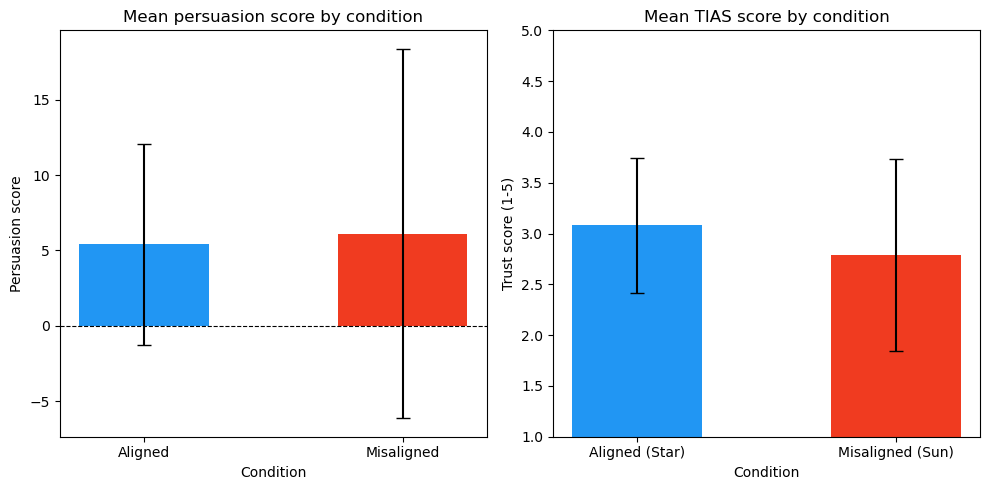

In [80]:
fig1, axes = plt.subplots(1, 2, figsize=(10, 5))

# Persuasion
persuasion_means = participant_persuasion.groupby("condition")["mean_persuasion"].agg(["mean", "std"])
axes[0].bar(persuasion_means.index, persuasion_means["mean"],
            yerr=persuasion_means["std"], capsize=5, color=["#2196F3", "#f03b20"], width=0.5)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Mean persuasion score by condition")
axes[0].set_ylabel("Persuasion score")
axes[0].set_xlabel("Condition")

# TIAS
axes[1].bar(["Aligned (Star)", "Misaligned (Sun)"],
            [qualtrics["tias_star"].mean(), qualtrics["tias_sun"].mean()],
            yerr=[qualtrics["tias_star"].std(), qualtrics["tias_sun"].std()],
            capsize=5, color=["#2196F3", "#f03b20"], width=0.5)
axes[1].set_ylim(1, 5)
axes[1].set_title("Mean TIAS score by condition")
axes[1].set_ylabel("Trust score (1-5)")
axes[1].set_xlabel("Condition")

plt.tight_layout()
plt.savefig("persuasion_trust_plot.png", dpi=150, bbox_inches="tight")
plt.show()

### Additional Questions

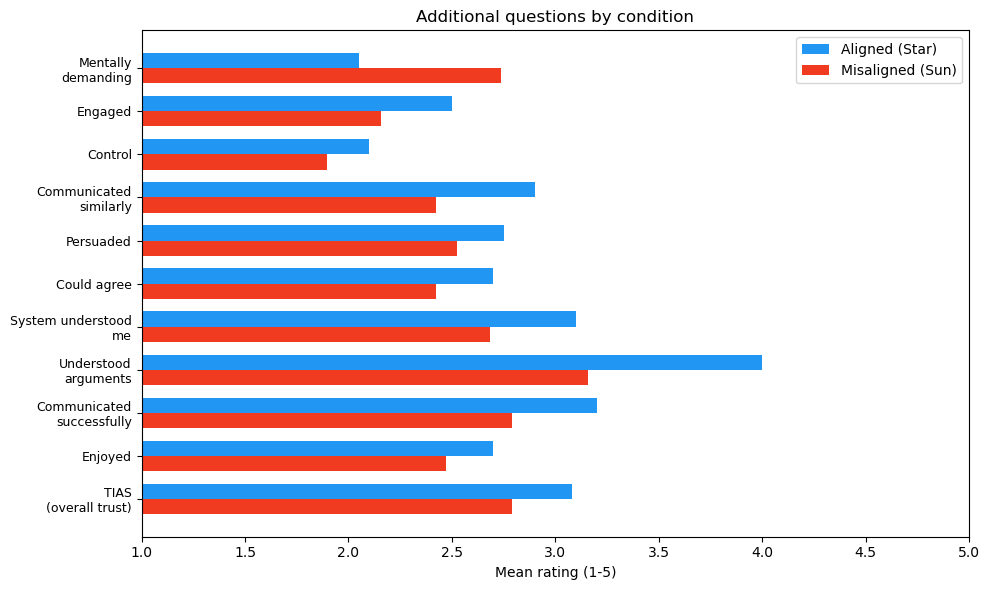

In [81]:
fig2, ax = plt.subplots(figsize=(10, 6))

questions_short = ["TIAS\n(overall trust)", "Enjoyed", "Communicated\nsuccessfully", "Understood\narguments",
                   "System understood\nme", "Could agree", "Persuaded",
                   "Communicated\nsimilarly", "Control", "Engaged", "Mentally\ndemanding"]
star_means = [pd.to_numeric(qualtrics[star], errors="coerce").mean() for _, star, _ in QUESTION_PAIRS]
sun_means = [pd.to_numeric(qualtrics[sun], errors="coerce").mean() for _, _, sun in QUESTION_PAIRS]

x = np.arange(len(questions_short))
width = 0.35
ax.barh(x + width/2, star_means, width, label="Aligned (Star)", color="#2196F3")
ax.barh(x - width/2, sun_means, width, label="Misaligned (Sun)", color="#f03b20")
ax.set_yticks(x)
ax.set_yticklabels(questions_short, fontsize=9)
ax.set_xlim(1, 5)
ax.set_title("Additional questions by condition")
ax.set_xlabel("Mean rating (1-5)")
ax.legend()

plt.tight_layout()
plt.savefig("additional_questions_plot.png", dpi=150, bbox_inches="tight")
plt.show()

### Persuasion by participant

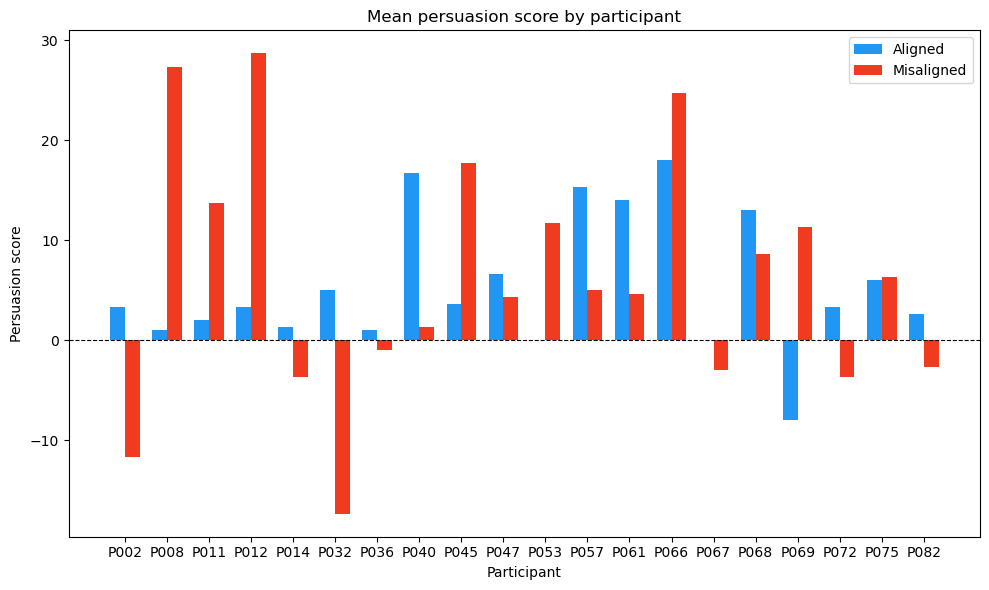

In [82]:
fig, ax = plt.subplots(figsize=(10, 6))
participant_pivot = sessions_clean.groupby(["participant_id", "condition"])["persuasion_score"].mean().unstack()
x = np.arange(len(participant_pivot))
width = 0.35

ax.bar(x - width/2, participant_pivot["Aligned"], width, label="Aligned", color="#2196F3")
ax.bar(x + width/2, participant_pivot["Misaligned"], width, label="Misaligned", color="#f03b20")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(participant_pivot.index)
ax.set_title("Mean persuasion score by participant")
ax.set_ylabel("Persuasion score")
ax.set_xlabel("Participant")
ax.legend()

plt.tight_layout()
plt.savefig("persuasion_by_participant.png", dpi=150, bbox_inches="tight")
plt.show()

### Correlation

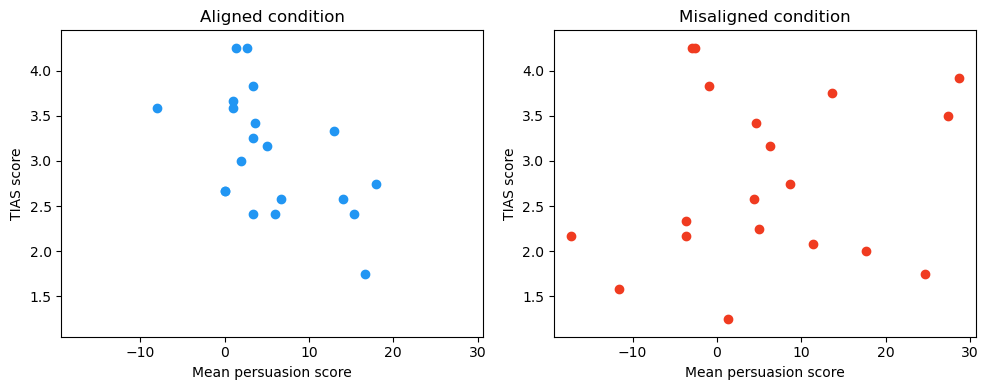

In [83]:
# scatter plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
all_persuasion = combined["persuasion_score"]
all_trust = combined["tias_score"]
x_min, x_max = all_persuasion.min() - 2, all_persuasion.max() + 2
y_min, y_max = all_trust.min() - 0.2, all_trust.max() + 0.2

for i, condition in enumerate(["Aligned", "Misaligned"]):
    subset = combined[combined["condition"] == condition]
    axes[i].scatter(subset["persuasion_score"], subset["tias_score"],
                    color="#2196F3" if condition == "Aligned" else "#f03b20")
    axes[i].set_xlabel("Mean persuasion score")
    axes[i].set_ylabel("TIAS score")
    axes[i].set_title(f"{condition} condition")
    axes[i].set_xlim(x_min, x_max)
    axes[i].set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig("trust_persuasion_correlation.png", dpi=150, bbox_inches="tight")
plt.show()